In [1]:
import tensorflow as tf
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Resizing
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Conv2DTranspose
from tensorflow.keras.layers import concatenate
from tensorflow.keras.layers import Layer
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
import numpy as np
import cv2

class FeatureEncryptionLayer(Layer):
    def __init__(self, encryption_strength=0.5, use_random_projection=True, **kwargs):
        super().__init__(**kwargs)
        self.encryption_strength = encryption_strength
        self.use_random_projection = use_random_projection

    def build(self, input_shape):
        # Create learnable encryption matrix
        self.encryption_matrix = self.add_weight(
            name='encryption_matrix',
            shape=(input_shape[-1], input_shape[-1]),
            initializer='orthogonal',
            trainable=True
        )
        
        # Create bias for additional obfuscation
        self.encryption_bias = self.add_weight(
            name='encryption_bias',
            shape=(input_shape[-1],),
            initializer='zeros',
            trainable=True
        )
        
        if self.use_random_projection:
            # Fixed random projection matrix (not trainable)
            self.random_projection = self.add_weight(
                name='random_projection',
                shape=(input_shape[-1], input_shape[-1]),
                initializer='random_normal',
                trainable=False
            )
    def call(self, inputs, training=None):
        # Apply learnable transformation
        encrypted = tf.matmul(inputs, self.encryption_matrix) + self.encryption_bias
        
        # Apply random projection if enabled
        if self.use_random_projection:
            encrypted = tf.matmul(encrypted, self.random_projection)
        
        # Mix original and encrypted features based on strength
        mixed = (1 - self.encryption_strength) * inputs + self.encryption_strength * encrypted
        
        return mixed
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'encryption_strength': self.encryption_strength,
            'use_random_projection': self.use_random_projection
        })
        return config

class GaussianNoiseLayer(tf.keras.layers.Layer):
    def __init__(self, stddev, training_only=True, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev
        self.training_only = training_only
    
    def call(self, inputs, training=None):
        if self.training_only and not training:
            return inputs
        noise = tf.random.normal(tf.shape(inputs), mean=0.0, stddev=self.stddev)
        return inputs + noise
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'stddev': self.stddev,
            'training_only': self.training_only
        })
        return config
    
class GaussianBlur(Layer):
    def __init__(self, kernel_size=5, sigma=1.0, **kwargs):
        super(GaussianBlur, self).__init__(**kwargs)
        self.kernel_size = kernel_size
        self.sigma = sigma

    def build(self, input_shape):
        ax = tf.range(-self.kernel_size // 2 + 1, self.kernel_size // 2 + 1, dtype=tf.float32)
        xx, yy = tf.meshgrid(ax, ax)
        kernel = tf.exp(-(xx**2 + yy**2) / (2. * self.sigma**2))
        kernel = kernel / tf.reduce_sum(kernel)
        kernel = tf.expand_dims(kernel, axis=-1)
        kernel = tf.expand_dims(kernel, axis=-1)
        kernel = tf.repeat(kernel, input_shape[-1], axis=-1)
        self.kernel = tf.Variable(kernel, trainable=False)

    def call(self, x):
        return tf.nn.depthwise_conv2d(x, self.kernel, strides=[1, 1, 1, 1], padding='SAME')

class WeightNoiseLayer(tf.keras.layers.Layer):
    def __init__(self, stddev, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev
    
    def call(self, inputs):
        noise = tf.random.normal(tf.shape(inputs), mean=0.0, stddev=self.stddev)
        return inputs + noise
    
    def get_config(self):
        config = super().get_config()
        config.update({'stddev': self.stddev})
        return config

class MixupLayer(tf.keras.layers.Layer):
    def __init__(self, alpha=0.2, **kwargs):
        super().__init__(**kwargs)
        self.alpha = alpha
    
    def call(self, inputs, training=None):
        if not training:
            return inputs
        
        batch_size = tf.shape(inputs)[0]
        indices = tf.random.shuffle(tf.range(batch_size))
        shuffled_inputs = tf.gather(inputs, indices)
        
        # Generate lambda from uniform distribution (approximating Beta)
        lam = tf.random.uniform([], 0, self.alpha)
        mixed_inputs = lam * inputs + (1 - lam) * shuffled_inputs
        
        return mixed_inputs
    
    def get_config(self):
        config = super().get_config()
        config.update({'alpha': self.alpha})
        return config

class PrivacyPreservingUNet:
    def __init__(self, 
                 input_size=(None, None, 1), 
                 target_size=(128, 128), 
                 num_classes=4,
                 privacy_config=None):
        """
        Privacy-preserving U-Net using only native TensorFlow/Keras
        
        Args:
            privacy_config: dict with privacy settings
                - 'gradient_noise': float, noise level for gradient perturbation (default: 0.1)
                - 'gradient_clipping': float, gradient clipping value (default: 1.0)
                - 'input_noise': float, input perturbation level (default: 0.01)
                - 'weight_noise': float, weight noise injection (default: 0.001)
                - 'privacy_dropout': float, enhanced dropout for privacy (default: 0.2)
                - 'label_smoothing': float, label smoothing for privacy (default: 0.1)
                - 'mixup_alpha': float, mixup augmentation parameter (default: 0.2)
                - 'feature_noise': bool, add noise to intermediate features
        """
        self.input_size = input_size
        self.target_size = target_size
        self.num_classes = num_classes
        
        # Default privacy configuration
        self.privacy_config = {
            'gradient_noise': 0.1,
            'gradient_clipping': 1.0,
            'input_noise': 0.01,
            'weight_noise': 0.001,
            'privacy_dropout': 0.2,
            'label_smoothing': 0.1,
            'mixup_alpha': 0.2,
            'feature_noise': True
        }
        
        if privacy_config:
            self.privacy_config.update(privacy_config)

        print("Privacy configuration:")
        for key, value in self.privacy_config.items():
            print(f"  {key}: {value}")
    
    def add_gaussian_noise_layer(self, x, noise_stddev=0.01, training_only=True, name="noise"):
        """Add Gaussian noise layer for privacy protection"""
        return GaussianNoiseLayer(stddev=noise_stddev, training_only=training_only, name=name)(x)
    
    def add_encryption_layer(self, x, layer_name):
        """Add appropriate encryption layer based on configuration"""
        if not self.privacy_config.get('feature_encryption', False):
            return x
        
        return FeatureEncryptionLayer(
            encryption_strength=self.privacy_config.get('encryption_strength', 0.5),
            use_random_projection=True,
            name=f"{layer_name}_encryption"
        )(x)
    
    def privacy_aware_conv_block(self, x, noise_stddev, filters, block_name, dropout_rate=0.1, add_feature_noise=False):
        """Convolutional block with privacy-enhancing modifications"""
        # First convolution
        conv = Conv2D(filters, (3, 3), activation='relu', padding='same', 
                     kernel_initializer='he_normal', 
                     kernel_regularizer=tf.keras.regularizers.l2(0.001),
                     name=f"{block_name}_conv1")(x)
        
        # Add feature noise for privacy
        if add_feature_noise:
            conv = self.add_gaussian_noise_layer(
                conv, noise_stddev=noise_stddev, name=f"{block_name}_feature_noise1"
            )
        
        conv = BatchNormalization(name=f"{block_name}_bn1")(conv)
        
        # Second convolution
        conv = Conv2D(filters, (3, 3), activation='relu', padding='same', 
                     kernel_initializer='he_normal',
                     kernel_regularizer=tf.keras.regularizers.l2(0.001),
                     name=f"{block_name}_conv2")(conv)
        
        conv = self.add_encryption_layer(conv, f"{block_name}_conv2")
        
        if add_feature_noise and self.privacy_config.get('feature_noise', False):
            conv = self.add_gaussian_noise_layer(
                conv, noise_stddev=0.005, name=f"{block_name}_feature_noise2"
            )
        
        conv = BatchNormalization(name=f"{block_name}_bn2")(conv)
        
        # Enhanced dropout for privacy
        privacy_dropout = max(dropout_rate, self.privacy_config.get('privacy_dropout', 0.2))
        conv = Dropout(privacy_dropout, name=f"{block_name}_dropout")(conv)
        
        return conv
    
    def add_weight_noise_layer(self, x, noise_stddev=0.001, name="weight_noise"):
        """Add noise to simulate weight perturbation"""
        return WeightNoiseLayer(stddev=noise_stddev, name=name)(x)
    
    def mixup_layer(self, x, y=None, alpha=0.2, name="mixup"):
        """Mixup augmentation for privacy protection"""
        return MixupLayer(alpha=alpha, name=name)(x)

    
    def build_model(self):
        inputs = Input(self.input_size, name="input_layer")
    
        # Preprocessing
        x = tf.keras.layers.Resizing(self.target_size[0], self.target_size[1], name="resize")(inputs)
        x = tf.keras.layers.Rescaling(1./255, name="rescale")(x)
        
        # Optional input noise for privacy
        noise_stddev = self.privacy_config.get('input_noise', 0.01)
        drop_out_rate = max(self.privacy_config.get('privacy_dropout', 0.2), 0.1)
        add_feature_noise = self.privacy_config.get('feature_noise', False)
        
        print(f"Adding input noise with stddev: {noise_stddev}, dropout rate: {drop_out_rate}, feature noise: {add_feature_noise}")

        x = GaussianBlur(name="gaussian_blur")(x)

        if self.privacy_config.get('input_noise', 0) > 0:
            x = self.add_gaussian_noise_layer(x, noise_stddev=noise_stddev , name="input_noise")
        
        # Block 1

        c1 = self.privacy_aware_conv_block(x, noise_stddev= noise_stddev,  filters=32, block_name="encoder_block1", 
                                          dropout_rate= drop_out_rate, add_feature_noise=add_feature_noise)
        p1 = MaxPooling2D((2, 2), name="pool1")(c1)

        # Block 2
        c2 = self.privacy_aware_conv_block(p1, noise_stddev= noise_stddev, filters=64, block_name="encoder_block2", 
                                          dropout_rate=drop_out_rate, add_feature_noise=add_feature_noise)
        p2 = MaxPooling2D((2, 2), name="pool2")(c2)

        # Block 3
        c3 = self.privacy_aware_conv_block(p2, noise_stddev= noise_stddev, filters=128, block_name="encoder_block3", 
                                          dropout_rate=drop_out_rate, add_feature_noise=add_feature_noise)
        p3 = MaxPooling2D((2, 2), name="pool3")(c3)

        # Bottleneck
        c4 = self.privacy_aware_conv_block(p3, noise_stddev= noise_stddev, filters=256, block_name="bottleneck", 
                                          dropout_rate=drop_out_rate, add_feature_noise=add_feature_noise)
        
        # Add weight noise to bottleneck if configured
        weight_noise = self.privacy_config.get('weight_noise', 0.001)

        if self.privacy_config.get('weight_noise', 0) > 0:
            c4 = self.add_weight_noise_layer(c4, noise_stddev=weight_noise, 
                                           name="bottleneck_weight_noise")

        # Decoder Path using privacy-aware blocks
        
        # Block 5
        u5 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same', name="upsample5")(c4)
        u5 = concatenate([u5, c3], name="concat5")
        c5 = self.privacy_aware_conv_block(u5, noise_stddev= noise_stddev, filters=128, block_name="decoder_block5", 
                                          dropout_rate=drop_out_rate, add_feature_noise=add_feature_noise)

        # Block 6
        u6 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same', name="upsample6")(c5)
        u6 = concatenate([u6, c2], name="concat6")
        c6 = self.privacy_aware_conv_block(u6, noise_stddev= noise_stddev, filters=64, block_name="decoder_block6", 
                                          dropout_rate=drop_out_rate, add_feature_noise=add_feature_noise)

        # Block 7
        u7 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same', name="upsample7")(c6)
        u7 = concatenate([u7, c1], name="concat7")
        c7 = self.privacy_aware_conv_block(u7, noise_stddev= noise_stddev, filters=32, block_name="decoder_block7", 
                                          dropout_rate=drop_out_rate, add_feature_noise=add_feature_noise)

        # Output layer
        outputs = Conv2D(self.num_classes, (1, 1), activation='softmax', name="output_layer")(c7)

        model = Model(inputs, outputs, name="privacy_preserving_unet")
        return model
    @staticmethod
    def load_model(model_path):
        """
        Load a pre-trained model with custom objects
        """
        custom_objects = {
            'GaussianBlur': GaussianBlur,
            'GaussianNoiseLayer': GaussianNoiseLayer,
            'WeightNoiseLayer': WeightNoiseLayer,
            'MixupLayer': MixupLayer,
            'dice_coefficient_multiclass': dice_coefficient_multiclass,
            'iou_metric_multiclass': iou_metric_multiclass
        }
        return tf.keras.models.load_model(model_path, custom_objects=custom_objects)
       

# Custom optimizer with gradient noise and clipping
class PrivacyAwareOptimizer:
    def __init__(self, base_optimizer, gradient_noise_stddev=0.1, gradient_clip_value=1.0):
        self.base_optimizer = base_optimizer
        self.gradient_noise_stddev = gradient_noise_stddev
        self.gradient_clip_value = gradient_clip_value
    
    def get_optimizer(self):
        """Get optimizer with privacy-preserving modifications"""
        # Note: This is a conceptual implementation
        # In practice, you would need to implement custom training loop
        return self.base_optimizer

# Custom training function with privacy techniques
def train_with_privacy_techniques(model, train_data, val_data, privacy_config, 
                                 epochs=100, batch_size=32):
    """
    Custom training function with privacy-preserving techniques
    """

    img_train, label_train = train_data
    
    # Compile model with privacy-aware settings
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=1e-4,
        clipnorm=privacy_config.get('gradient_clipping', 1.0)  # Gradient clipping
    )
    

    model.compile(
        optimizer=optimizer,
        loss= 'sparse_categorical_crossentropy',
        metrics=['accuracy', dice_coefficient_multiclass, iou_metric_multiclass]
    )
    
    # Custom callbacks for privacy
    callbacks = [
        tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5),
    ]
    
    
    print("Privacy-preserving training configuration:")
    for key, value in privacy_config.items():
        print(f"  {key}: {value}")
    
    history = model.fit(
        img_train, label_train,
        validation_data=val_data,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
    )
    
    return history

def dice_coefficient_multiclass(y_true, y_pred, smooth=1e-6):
        """Dice coefficient for multi-class segmentation with sparse labels"""
        # Convert sparse labels to one-hot if needed
        if len(y_true.shape) != len(y_pred.shape):
            y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=tf.shape(y_pred)[-1])
            y_true = tf.cast(y_true, tf.float32)
        
        # Flatten tensors
        y_true_f = tf.reshape(y_true, [-1, tf.shape(y_true)[-1]])
        y_pred_f = tf.reshape(y_pred, [-1, tf.shape(y_pred)[-1]])
        
        intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=0)
        union = tf.reduce_sum(y_true_f, axis=0) + tf.reduce_sum(y_pred_f, axis=0)
        dice = (2. * intersection + smooth) / (union + smooth)
        
        return tf.reduce_mean(dice)

def dice_loss_multiclass(y_true, y_pred, smooth=1e-6):
    """Dice loss for multi-class segmentation"""
    return 1 - dice_coefficient_multiclass(y_true, y_pred, smooth)

# IoU Metric for multi-class
def iou_metric_multiclass(y_true, y_pred, smooth=1e-6):
    # Convert predictions to class labels
    y_pred = tf.argmax(y_pred, axis=-1)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true = tf.cast(y_true, tf.float32)

    # Flatten
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(tf.cast(y_true_f == y_pred_f, tf.float32))
    union = tf.cast(tf.size(y_true_f, out_type=tf.int32), tf.float32)

    return (intersection + smooth) / (union + smooth)


# Improved Learning Rate Scheduler
def scheduler(epoch, lr):
    if epoch < 10:
        return lr
    elif epoch < 20:
        return lr * 0.5
    else:
        return lr * 0.1

# Factory function for different privacy levels


2025-07-19 08:46:15.787029: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-19 08:46:16.006790: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752894976.084068    2447 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752894976.107430    2447 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752894976.290512    2447 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
def create_lightweight_privacy_unet(privacy_level="medium"):
    """
    Create U-Net with different privacy levels using only native TensorFlow
    """
    privacy_configs = {
        "low": {
            'input_noise': 0.005,
            'privacy_dropout': 0.15,
            'gradient_clipping': 2.0,
            'label_smoothing': 0.05,
            'feature_noise': False,
            'feature_encryption': False,
            'encryption_type': 'learnable',  # or 'homomorphic' or 'smpc'
            'encryption_strength': 0.7,
        },
        "medium": {
            'gradient_noise': 0.5,
            'gradient_clipping': 1.0,
            'input_noise': 0.05,
            'weight_noise': 0.01,
            'privacy_dropout': 0.2,
            'label_smoothing': 0.1,
            'mixup_alpha': 0.2,
            'feature_noise': True,
            'feature_encryption': True,
            'encryption_type': 'learnable',  # or 'homomorphic' or 'smpc'
            'encryption_strength': 0.5,
        },
        "high": {
            'gradient_noise': 1,
            'gradient_clipping': 0.5,
            'input_noise': 0.2,
            'weight_noise': 0.05,
            'privacy_dropout': 0.5,
            'label_smoothing': 0.2,
            'mixup_alpha': 0.3,
            'feature_noise': True,
            'feature_encryption': True,
            'encryption_type': 'learnable',  # or 'homomorphic' or 'smpc'
            'encryption_strength': 0.75,
        }
    }
    
    config = privacy_configs.get(privacy_level, privacy_configs["medium"])
    
    privacy_unet = PrivacyPreservingUNet(
        input_size=(None, None, 1),
        target_size=(128, 128),
        num_classes=4,
        privacy_config=config
    )
    
    model = privacy_unet.build_model()
    
    return model, config

In [3]:
import os

def load_images_label_pairs(images , labels, image_dir, label_dir, step=1, step_size=1000, add_noise=False):
    image_files = sorted(os.listdir(image_dir))  # Sort to maintain consistency
    label_files = sorted(os.listdir(label_dir))

    images =[]
    labels=[]

    # currupted_images = [2355, 2365, 2366]
    print("Images count: " + str(len(image_files)))
    for img, label in zip(image_files[step * step_size: (step + 1) * step_size], label_files[step * step_size: (step + 1) * step_size]):
        # print("Processing image: " + img + " with label: " + label)
        img_path = os.path.join(image_dir, img)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Adjust if images are colored
        if add_noise == True:
            noise = np.random.normal(loc=0, scale=10, size=img.shape).astype(np.float32)
            img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
        img = cv2.resize(img, (128, 128))
        images.append(img)


        label_path = os.path.join(label_dir, label)
        label = np.load(label_path)
        label = cv2.resize(label, (128, 128))  # Resize to match the image size
        labels.append(label)

    # return images, labels
    return np.array(images), np.array(labels)

In [4]:
image_dir_path = '/home/yasas/GazeEstimation/openEDS/openEDS/train/images'
label_dir_path = '/home/yasas/GazeEstimation/openEDS/openEDS/train/labels'


images = []
labels = []

images, labels = load_images_label_pairs(images , labels , image_dir_path, label_dir_path, step=0, step_size=10000, add_noise=True)

Images count: 27431


In [ ]:
from sklearn.model_selection import train_test_split

model_medium, config = create_lightweight_privacy_unet(privacy_level="low")

img_train, img_test, label_train, label_test = train_test_split(images, labels, test_size=0.2, random_state=42)

history = train_with_privacy_techniques(model=model_medium, 
                              train_data=(img_train, label_train), 
                              val_data=(img_test, label_test), 
                              privacy_config=config, 
                              epochs=50, 
                              batch_size=8)

dice_history = history.history['dice_coefficient_multiclass']
iou_history  = history.history['iou_metric_multiclass']

print("Train Dice (each epoch):", dice_history)
print("Train IoU  (each epoch):", iou_history)

# If you want the final epoch only:
print("Final train Dice:", dice_history[-1])
print("Final train IoU :",  iou_history[-1])

# The same keys prefixed with 'val_' hold your validation curves
print("Final val Dice:", history.history['val_dice_coefficient_multiclass'][-1])
print("Final val IoU :", history.history['val_iou_metric_multiclass'][-1])


model_medium.save('privacy_preserving_unet_low.h5')

In [5]:
from sklearn.model_selection import train_test_split

model_medium, config = create_lightweight_privacy_unet(privacy_level="medium")

img_train, img_test, label_train, label_test = train_test_split(images, labels, test_size=0.2, random_state=42)

history = train_with_privacy_techniques(model=model_medium, 
                              train_data=(img_train, label_train), 
                              val_data=(img_test, label_test), 
                              privacy_config=config, 
                              epochs=50, 
                              batch_size=8)

dice_history = history.history['dice_coefficient_multiclass']
iou_history  = history.history['iou_metric_multiclass']

print("Train Dice (each epoch):", dice_history)
print("Train IoU  (each epoch):", iou_history)

# If you want the final epoch only:
print("Final train Dice:", dice_history[-1])
print("Final train IoU :",  iou_history[-1])

# The same keys prefixed with 'val_' hold your validation curves
print("Final val Dice:", history.history['val_dice_coefficient_multiclass'][-1])
print("Final val IoU :", history.history['val_iou_metric_multiclass'][-1])


model_medium.save('privacy_preserving_unet_medium.h5')

Privacy configuration:
  gradient_noise: 0.5
  gradient_clipping: 1.0
  input_noise: 0.05
  weight_noise: 0.01
  privacy_dropout: 0.2
  label_smoothing: 0.1
  mixup_alpha: 0.2
  feature_noise: True
  feature_encryption: True
  encryption_type: learnable
  encryption_strength: 0.5
Adding input noise with stddev: 0.05, dropout rate: 0.2, feature noise: True


I0000 00:00:1752895268.461804    2447 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3586 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Privacy-preserving training configuration:
  gradient_noise: 0.5
  gradient_clipping: 1.0
  input_noise: 0.05
  weight_noise: 0.01
  privacy_dropout: 0.2
  label_smoothing: 0.1
  mixup_alpha: 0.2
  feature_noise: True
  feature_encryption: True
  encryption_type: learnable
  encryption_strength: 0.5
Epoch 1/50


I0000 00:00:1752895285.102331    4640 service.cc:152] XLA service 0x1f7728c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1752895285.102397    4640 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2025-07-19 08:51:25.604192: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1752895288.553841    4640 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-07-19 08:51:36.977201: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_8', 260 bytes spill stores, 260 bytes spill loads

2025-07-19 08:51:37.322232: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7540 - dice_coefficient_multiclass: 0.3975 - iou_metric_multiclass: 0.7540 - loss: 2.9163

2025-07-19 08:53:14.126269: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_8', 404 bytes spill stores, 400 bytes spill loads

2025-07-19 08:53:14.514052: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6_0', 16 bytes spill stores, 16 bytes spill loads

2025-07-19 08:53:16.149179: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_8', 672 bytes spill stores, 544 bytes spill loads

2025-07-19 08:53:16.525601: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6', 592 bytes spill stores, 500 bytes spill loads

2025-07-19 08:53:16.568574: I external/local

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 133s 64ms/step - accuracy: 0.7542 - dice_coefficient_multiclass: 0.3976 - iou_metric_multiclass: 0.7542 - loss: 2.9155 - val_accuracy: 0.8639 - val_dice_coefficient_multiclass: 0.3326 - val_iou_metric_multiclass: 0.8639 - val_loss: 1.7611 - learning_rate: 1.0000e-04
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 51s 51ms/step - accuracy: 0.9793 - dice_coefficient_multiclass: 0.7652 - iou_metric_multiclass: 0.9793 - loss: 1.1404 - val_accuracy: 0.8932 - val_dice_coefficient_multiclass: 0.5283 - val_iou_metric_multiclass: 0.8932 - val_loss: 1.0818 - learning_rate: 1.0000e-04
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 52s 52ms/step - accuracy: 0.9837 - dice_coefficient_multiclass: 0.8452 - iou_metric_multiclass: 0.9837 - loss: 0.6243 - val_accuracy: 0.9229 - val_dice_coefficient_multiclass: 0.6613 - val_iou_metric_multiclass: 0.9229 - val_loss: 0.6382 - learning_rate: 1.0000e-04
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 51s 51ms/step - accuracy: 0.9857 - dice_coef

In [24]:
from sklearn.model_selection import train_test_split

model_medium, config = create_lightweight_privacy_unet(privacy_level="high")

img_train, img_test, label_train, label_test = train_test_split(images, labels, test_size=0.2, random_state=42)

history = train_with_privacy_techniques(model=model_medium, 
                              train_data=(img_train, label_train), 
                              val_data=(img_test, label_test), 
                              privacy_config=config, 
                              epochs=50, 
                              batch_size=8)

dice_history = history.history['dice_coefficient_multiclass']
iou_history  = history.history['iou_metric_multiclass']

print("Train Dice (each epoch):", dice_history)
print("Train IoU  (each epoch):", iou_history)

# If you want the final epoch only:
print("Final train Dice:", dice_history[-1])
print("Final train IoU :",  iou_history[-1])

# The same keys prefixed with 'val_' hold your validation curves
print("Final val Dice:", history.history['val_dice_coefficient_multiclass'][-1])
print("Final val IoU :", history.history['val_iou_metric_multiclass'][-1])


model_medium.save('privacy_preserving_unet_high.h5')

Privacy configuration:
  gradient_noise: 1
  gradient_clipping: 0.5
  input_noise: 0.2
  weight_noise: 0.05
  privacy_dropout: 0.5
  label_smoothing: 0.2
  mixup_alpha: 0.3
  feature_noise: True
Adding input noise with stddev: 0.2, dropout rate: 0.5, feature noise: True
Privacy-preserving training configuration:
  gradient_noise: 1
  gradient_clipping: 0.5
  input_noise: 0.2
  weight_noise: 0.05
  privacy_dropout: 0.5
  label_smoothing: 0.2
  mixup_alpha: 0.3
  feature_noise: True
Epoch 1/50


2025-07-18 16:05:06.767205: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_1', 96 bytes spill stores, 96 bytes spill loads



1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5923 - dice_coefficient_multiclass: 0.2711 - iou_metric_multiclass: 0.5923 - loss: 3.4549

2025-07-18 16:05:47.398242: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_concatenate_fusion', 4 bytes spill stores, 4 bytes spill loads



1000/1000 ━━━━━━━━━━━━━━━━━━━━ 87s 43ms/step - accuracy: 0.5925 - dice_coefficient_multiclass: 0.2712 - iou_metric_multiclass: 0.5925 - loss: 3.4539 - val_accuracy: 0.8495 - val_dice_coefficient_multiclass: 0.2383 - val_iou_metric_multiclass: 0.8495 - val_loss: 1.9043 - learning_rate: 1.0000e-04
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 40s 40ms/step - accuracy: 0.9530 - dice_coefficient_multiclass: 0.6005 - iou_metric_multiclass: 0.9530 - loss: 1.2990 - val_accuracy: 0.8495 - val_dice_coefficient_multiclass: 0.2346 - val_iou_metric_multiclass: 0.8495 - val_loss: 1.5166 - learning_rate: 1.0000e-04
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 44s 44ms/step - accuracy: 0.9631 - dice_coefficient_multiclass: 0.7042 - iou_metric_multiclass: 0.9631 - loss: 0.7800 - val_accuracy: 0.8495 - val_dice_coefficient_multiclass: 0.2323 - val_iou_metric_multiclass: 0.8495 - val_loss: 1.3394 - learning_rate: 1.0000e-04
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.9677 - dice_coeff

Train Dice (each epoch): [0.375276118516922, 0.6347699165344238, 0.7198463082313538, 0.7623717188835144, 0.7890836596488953, 0.809922456741333, 0.8241173624992371, 0.8326258659362793, 0.8411300778388977, 0.8466570973396301, 0.8516564965248108, 0.8550492525100708, 0.8579869866371155, 0.8608154058456421, 0.862772524356842, 0.8653470277786255, 0.8657587170600891, 0.8678086400032043, 0.8698862195014954, 0.8701143264770508, 0.8710882663726807, 0.8721808195114136, 0.8808003664016724, 0.8826704025268555, 0.8823541402816772, 0.883205771446228, 0.883926510810852, 0.8844501376152039, 0.8899201154708862, 0.8900840878486633, 0.8908892273902893, 0.8909669518470764, 0.8916279673576355]
Train IoU  (each epoch): [0.7899595499038696, 0.9564385414123535, 0.964582622051239, 0.9682723879814148, 0.9705165028572083, 0.9722602963447571, 0.9735801815986633, 0.974058210849762, 0.9751353859901428, 0.9755050539970398, 0.9759947657585144, 0.9764881134033203, 0.9768576622009277, 0.9771050810813904, 0.9772827029228

In [2]:
model = PrivacyPreservingUNet.load_model('privacy_preserving_unet.h5')

I0000 00:00:1751084142.898532  204464 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3586 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Original image shape: (400, 640)


1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Predicted mask shape: (128, 128)


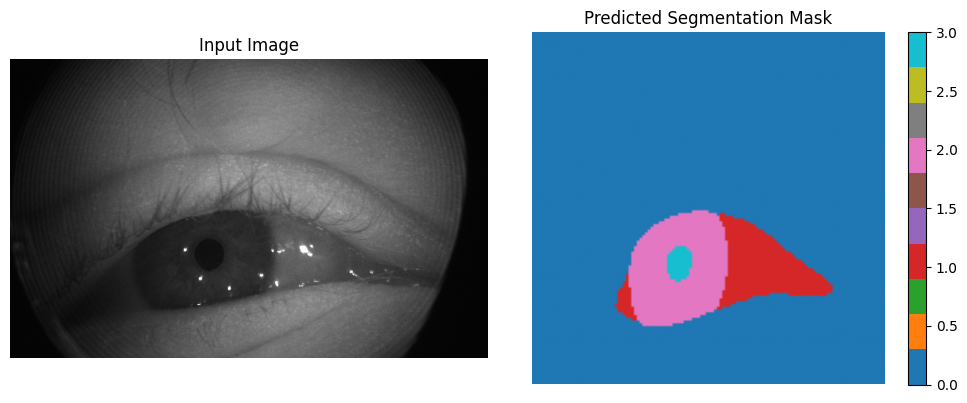

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

image_path = '/home/yasas/GazeEstimation/openEDS/openEDS/train/images/008110.png'

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
print("Original image shape:", image.shape)
img_input = np.expand_dims(image, axis=(0, -1))  # e.g., (1, 240, 320, 1)

custom_objects = {
            'GaussianBlur': GaussianBlur,
            'GaussianNoiseLayer': GaussianNoiseLayer,
            'WeightNoiseLayer': WeightNoiseLayer,
            'MixupLayer': MixupLayer,
            'FeatureEncryptionLayer': FeatureEncryptionLayer,
            'dice_coefficient_multiclass': dice_coefficient_multiclass,
            'iou_metric_multiclass': iou_metric_multiclass
        }
model = tf.keras.models.load_model("privacy_preserving_unet_high.h5", custom_objects=custom_objects)


# Step 4: Predict with the model
pred = model.predict(img_input)  # Output shape: (1, 128, 128, 4) due to resizing inside model

# Step 5: Convert softmax to class labels
predicted_mask = np.argmax(pred, axis=-1)[0]  # Shape: (128, 128)
print("Predicted mask shape:", predicted_mask.shape)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Input Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(predicted_mask, cmap='tab10', vmin=0, vmax=3)
plt.title("Predicted Segmentation Mask")
plt.colorbar()
plt.axis('off')

plt.tight_layout()
plt.show()

plt.tight_layout()